[<< Sommaire QC](../README.md) | [Precedent : QC-Py-33-RL-PPO-Trading <<](./QC-Py-33-RL-PPO-Trading.ipynb) | [Suivant : QC-Py-40-PaperTrading-Binance >>](./QC-Py-40-PaperTrading-Binance.ipynb)

# QC-Py-34 - SAC et A2C : Comparaison d'Agents RL pour le Trading

> **Niveau** : Avance | **Pre-requis** : QC-Py-33 (PPO) | **Temps** : 90 min

> **Objectif** : Implementer et comparer deux familles d'agents RL sur le meme
> environnement de trading : SAC (Soft Actor-Critic, off-policy) et A2C (Advantage
> Actor-Critic, on-policy synchrone).

> **References** : Haarnoja et al. (2018) "Soft Actor-Critic", Mnih et al. (2016)
> "Asynchronous Methods for Deep RL", Hands-On AI Trading, chap. 12-13.

> **[REFERENCE QC Cloud]** Ce notebook compare SAC et A2C, deux paradigmes RL distincts,
> sur un environnement de trading avec 15 actions S&P 500.
>
> **Plan** :
> 1. **Contexte** : Positionner SAC et A2C par rapport a DQN et PPO
> 2. **SAC Discret** : Entropy-regularized off-policy avec double Q-learning
> 3. **A2C** : Synchronous advantage actor-critic
> 4. **Benchmark** : Entrainement 100K steps, comparaison DQN/PPO/SAC/A2C
> 5. **Synthese** : Tableau comparatif et recommandations

---

## Partie 1 : Positionnement dans le paysage RL (10 min)

### Quatre algorithmes, deux axes

Apres avoir etudie le DQN (off-policy, value-based) et le PPO (on-policy, policy gradient),
nous explorons deux approches supplementaires :

| Axe | On-policy | Off-policy |
|-----|-----------|------------|
| **Value-based** | - | DQN (QC-Py-32) |
| **Policy gradient** | PPO (QC-Py-33), **A2C** | **SAC** |

**SAC (Soft Actor-Critic)** :
- Off-policy : reutilise les experiences passees via un replay buffer
- Maximise la recompense ET l'entropie (exploration automatique)
- Double Q-network avec target smoothing pour stabilite
- Originallement pour actions continues, adapte ici pour actions discretes

**A2C (Advantage Actor-Critic)** :
- On-policy synchrone (version simplifiee de A3C sans parallelisme)
- Utilise l'avantage (reward - baseline) pour reduire la variance
- Plus simple et plus rapide que PPO (pas de clipping, pas de PPO epochs)
- Moins stable que PPO mais plus rapide a converger

> *Ancre savante -- Sutton, R.S. & Barto, A.G. (2018), Reinforcement Learning: An Introduction (2nd ed.), MIT Press, ISBN 978-0-262-03924-6. (Manuel de reference du RL : formalise la taxonomie value-based vs policy-gradient et on-policy vs off-policy utilisee ici pour positionner DQN/PPO/A2C/SAC ; source canonique des concepts de politique, fonction de valeur, avantage et equation de Bellman.)*


---

## Partie 2 : Environnement et Configuration (5 min)

In [1]:
# Imports et configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
from collections import deque
import time

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
print(f"Seed: {SEED}")

PyTorch: 2.11.0+cpu, CUDA: False
Device: cpu
Seed: 42


### Telechargement des donnees et environnement

Nous reutilisons le meme environnement que QC-Py-32 et QC-Py-33 pour une comparaison equitable.

In [2]:
# Telechargement des donnees
import yfinance as yf
from datetime import datetime

TRADE_TICKERS = [
    "BAC", "KO", "PFE", "CVX", "LLY",
    "COST", "JPM", "V", "UNH", "XOM",
    "MA", "JNJ", "PG", "HD", "MRK",
]

END_DATE = datetime(2025, 1, 1)
START_DATE = datetime(2014, 1, 1)
VAL_START = datetime(2022, 1, 1)

print(f"Telechargement de {len(TRADE_TICKERS)} actions...")
data = yf.download(TRADE_TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)
close_prices = data["Close"].dropna(axis=1, how="all")
volume_data = data["Volume"].dropna(axis=1, how="all")
valid_tickers = [t for t in TRADE_TICKERS if t in close_prices.columns]
print(f"Tickers valides: {len(valid_tickers)}/{len(TRADE_TICKERS)}")
print(f"Periode: {close_prices.index[0].strftime('%Y-%m-%d')} au {close_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Jours de bourse: {len(close_prices)}")

Telechargement de 15 actions...


[                       0%                       ]

[                       0%                       ]

[**********            20%                       ]  3 of 15 completed

[**********            20%                       ]  3 of 15 completed

...

[**********************80%*************          ]  12 of 15 completed

[**********************87%*****************      ]  13 of 15 completed

[**********************93%********************   ]  14 of 15 completed

[*********************100%***********************]  15 of 15 completed

Tickers valides: 15/15
Periode: 2014-01-02 au 2024-12-31
Jours de bourse: 2768


In [3]:
# Environnement de trading (identique QC-Py-32/33)
class TradingEnvironment:
    """Environnement de trading RL avec frictions realistes."""

    def __init__(self, prices, volumes, initial_cash=100000, commission_bps=10,
                 slippage_bps=5, impact_coeff=0.1, borrow_cost=0.02):
        self.prices = prices.values if hasattr(prices, 'values') else prices
        self.volumes = volumes.values if hasattr(volumes, 'values') else volumes
        self.n_assets = self.prices.shape[1]
        self.initial_cash = initial_cash
        self.commission_rate = commission_bps / 10000
        self.slippage_rate = slippage_bps / 10000
        self.impact_coeff = impact_coeff
        self.borrow_cost = borrow_cost / 252
        self.n_actions = 4
        self.reset()

    def reset(self):
        self.cash = self.initial_cash
        self.positions = np.zeros(self.n_assets)
        self.cost_basis = np.zeros(self.n_assets)
        self.current_step = 0
        self.total_steps = len(self.prices) - 1
        self.portfolio_values = [self.initial_cash]
        self.returns = []
        self.trades_log = []
        return self._get_observation()

    def _get_observation(self):
        t = self.current_step
        lookback = min(t, 20)
        obs = []
        for i in range(self.n_assets):
            price_series = self.prices[t-lookback:t+1, i]
            if len(price_series) < 2 or price_series[-2] == 0:
                obs.extend([0.0] * 6)
                continue
            ret_1d = (price_series[-1] / price_series[-2]) - 1 if len(price_series) >= 2 else 0
            ret_5d = (price_series[-1] / price_series[-5]) - 1 if len(price_series) >= 5 else 0
            ret_20d = (price_series[-1] / price_series[0]) - 1
            vol_20d = np.std(np.diff(price_series) / price_series[:-1]) if len(price_series) >= 3 else 0.01
            pos_norm = self.positions[i] * self.prices[t, i] / self.initial_cash
            vol_ratio = 1.0
            if t < len(self.volumes) and self.volumes[t, i] > 0:
                avg_vol = np.mean(self.volumes[max(0, t-20):t+1, i])
                if avg_vol > 0:
                    vol_ratio = self.volumes[t, i] / avg_vol
            obs.extend([ret_1d, ret_5d, ret_20d, vol_20d, pos_norm, vol_ratio])
        return np.array(obs, dtype=np.float32)

    @property
    def observation_dim(self):
        return self.n_assets * 6

    def step(self, actions):
        t = self.current_step
        if t >= self.total_steps:
            return self._get_observation(), 0, True, {}
        old_value = self._portfolio_value(t)
        trade_amount = self.initial_cash * 0.10
        for i, action in enumerate(actions):
            price = self.prices[t, i]
            if price <= 0:
                continue
            avg_vol = np.mean(self.volumes[max(0, t-20):t+1, i]) if t < len(self.volumes) else 1e6
            shares_to_trade = trade_amount / price
            vol_impact = self.impact_coeff * (shares_to_trade / max(avg_vol, 1))
            exec_price = price * (1 + vol_impact)
            if action == 1:
                cost = exec_price * shares_to_trade * (1 + self.commission_rate + self.slippage_rate)
                if cost <= self.cash:
                    self.cash -= cost
                    self.positions[i] += shares_to_trade
                    self.cost_basis[i] = exec_price
            elif action == 2:
                if self.positions[i] > 0:
                    proceeds = exec_price * self.positions[i] * (1 - self.commission_rate - self.slippage_rate)
                    self.cash += proceeds
                    self.positions[i] = 0
                    self.cost_basis[i] = 0
                else:
                    shares = trade_amount / exec_price
                    borrow_cost = exec_price * shares * self.borrow_cost
                    proceeds = exec_price * shares * (1 - self.commission_rate - self.slippage_rate) - borrow_cost
                    self.cash += proceeds
                    self.positions[i] -= shares
            elif action == 3:
                if self.positions[i] != 0:
                    if self.positions[i] > 0:
                        proceeds = exec_price * abs(self.positions[i]) * (1 - self.commission_rate - self.slippage_rate)
                    else:
                        proceeds = -exec_price * abs(self.positions[i]) * (1 + self.commission_rate + self.slippage_rate)
                    self.cash += proceeds
                    self.positions[i] = 0
                    self.cost_basis[i] = 0
        for i in range(self.n_assets):
            if self.positions[i] < 0:
                self.cash -= abs(self.positions[i]) * self.prices[t, i] * self.borrow_cost
        self.current_step += 1
        new_value = self._portfolio_value(self.current_step)
        reward = (new_value - old_value) / old_value * 100
        self.portfolio_values.append(new_value)
        self.returns.append(reward)
        done = self.current_step >= self.total_steps or new_value < self.initial_cash * 0.5
        info = {"portfolio_value": new_value, "n_trades": len(self.trades_log)}
        return self._get_observation(), reward, done, info

    def _portfolio_value(self, t):
        if t >= len(self.prices):
            t = len(self.prices) - 1
        asset_value = np.sum(self.positions * self.prices[t])
        return self.cash + asset_value


split_idx = close_prices.index.get_loc(close_prices[close_prices.index >= VAL_START].index[0])
train_prices = close_prices.iloc[:split_idx].values.astype(np.float64)
train_volumes = volume_data.iloc[:split_idx].values.astype(np.float64)
val_prices = close_prices.iloc[split_idx:].values.astype(np.float64)
val_volumes = volume_data.iloc[split_idx:].values.astype(np.float64)

train_env = TradingEnvironment(train_prices, train_volumes)
val_env = TradingEnvironment(val_prices, val_volumes)

STATE_DIM = 6
ACTION_DIM = train_env.n_actions
N_ASSETS = train_env.n_assets

print(f"Environnement: {N_ASSETS} actifs, STATE_DIM={STATE_DIM}, ACTION_DIM={ACTION_DIM}")
print(f"Train: {train_env.total_steps} steps, Val: {val_env.total_steps} steps")

Environnement: 15 actifs, STATE_DIM=6, ACTION_DIM=4
Train: 2014 steps, Val: 752 steps


---### Exercice 1 : Environnement avec couts de transaction pour RLLes environnements RL de trading omettent souvent les couts de transaction, ce qui surestime la performance.**Objectif** : Ajouter des couts de transaction a l'environnement et observer l'impact sur l'agent.**Regles** :- Cout fixe par trade : 5 bps (0.05%)- Reward ajuste : `reward = pnl - cout_transaction`- Comparez SAC avec et sans couts (50 episodes chacun)- Affichez : reward cumule, nombre de trades, ratio reward/trade**Indices** :- # Indice : `cout = abs(action - prev_action) * prix * 0.0005`- # Indice : Comparez les deux courbes de reward sur le meme graphique

In [4]:
# Exercice 1 : Environnement avec couts de transaction# TODO etudiant : Ajouter 5 bps par trade et comparer# Indice : Modifier step() pour deduire les couts, comparer avec/sans# Etape 1 : Modifier l'environnement# Etape 2 : Entrainer SAC sans couts (baseline)# Etape 3 : Entrainer SAC avec couts# Etape 4 : Comparer reward, trades, ratioresult = None  # TODO etudiant : remplacer par l'environnement avec coutsprint("Exercice a completer")

---

## Partie 3 : SAC Discret (20 min)

### Soft Actor-Critic pour actions discretes

SAC (Haarnoja et al. 2018) maximise simultanement la recompense attendue et l'entropie
de la politique. Cette regularisation par l'entropie encourage l'exploration et evite
les convergences prematures.

**Objectif SAC** : $J(\pi) = \sum_t E_{(s,a) \sim \pi}[r(s,a) + \alpha H(\pi(\cdot|s))]$

Ou $H$ est l'entropie et $\alpha$ est le coefficient de temperature (adaptable automatiquement).

Pour les actions discretes, SAC utilise :
- **Double Q-network** : Deux evaluateurs Q pour reduire la surestimation
- **V-network** : Fonction de valeur separee (stabilise l'apprentissage)
- **Target networks** : Copie lente pour stabilite
- **Replay buffer** : Stocke les transitions pour reutilisation

> *Ancres savantes -- Haarnoja, T., Zhou, A., Abbeel, P. & Levine, S. (2018), Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor, ICML 2018 (arXiv:1801.01290) (algorithme SAC : actor-critic off-policy maximisant recompense ET entropie, double Q-network + target smoothing + temperature alpha auto-adaptable) ; Haarnoja, T., Zhou, A., Hartikainen, K. et al. (2018), Soft Actor-Critic Algorithms and Applications (arXiv:1812.05905) (cadre du RL a entropie maximale, justification theorique de la regularisation par l'entropie et de l'exploration automatique).)*


In [5]:
# Agent SAC Discret
class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states, dtype=np.float32),
                np.array(actions, dtype=np.int64),
                np.array(rewards, dtype=np.float32),
                np.array(next_states, dtype=np.float32),
                np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


class SACDiscreteAgent:
    """SAC pour actions discretes avec double Q et auto-temperature."""

    def __init__(self, state_dim, action_dim, hidden_dim=128, lr=3e-4,
                 gamma=0.99, tau=0.005, alpha_lr=3e-4, target_entropy_ratio=0.5):
        self.gamma = gamma
        self.tau = tau
        self.action_dim = action_dim

        # Q-networks (double)
        self.q1 = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        ).to(DEVICE)
        self.q2 = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        ).to(DEVICE)

        # Target networks
        self.q1_target = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        ).to(DEVICE)
        self.q2_target = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        ).to(DEVICE)
        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())

        # Policy network
        self.policy = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        ).to(DEVICE)
        self.policy_head = nn.Linear(hidden_dim, action_dim).to(DEVICE)

        # Auto-temperature
        target_entropy = -np.log(1.0 / action_dim) * target_entropy_ratio
        self.log_alpha = torch.zeros(1, requires_grad=True, device=DEVICE)
        self.target_entropy = target_entropy

        # Optimizers
        self.q_optimizer = torch.optim.AdamW(
            list(self.q1.parameters()) + list(self.q2.parameters()),
            lr=lr, weight_decay=1e-4
        )
        self.policy_optimizer = torch.optim.AdamW(
            list(self.policy.parameters()) + list(self.policy_head.parameters()),
            lr=lr, weight_decay=1e-4
        )
        self.alpha_optimizer = torch.optim.AdamW([self.log_alpha], lr=alpha_lr)

        self.replay_buffer = ReplayBuffer(capacity=50000)

    @property
    def alpha(self):
        return self.log_alpha.exp().item()

    def get_action(self, state, explore=True):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            features = self.policy(state_t)
            logits = self.policy_head(features)
            probs = F.softmax(logits, dim=-1)
            if explore:
                dist = Categorical(probs=probs)
                action = dist.sample()
            else:
                action = probs.argmax(dim=-1)
        return action.item()

    def update(self, batch_size=64):
        if len(self.replay_buffer) < batch_size:
            return {"q_loss": 0, "policy_loss": 0, "alpha": self.alpha}

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)
        states_t = torch.tensor(states).to(DEVICE)
        actions_t = torch.tensor(actions).to(DEVICE)
        rewards_t = torch.tensor(rewards).to(DEVICE)
        next_states_t = torch.tensor(next_states).to(DEVICE)
        dones_t = torch.tensor(dones).to(DEVICE)

        with torch.no_grad():
            next_features = self.policy(next_states_t)
            next_logits = self.policy_head(next_features)
            next_probs = F.softmax(next_logits, dim=-1)
            next_log_probs = F.log_softmax(next_logits, dim=-1)
            next_q1 = self.q1_target(next_states_t)
            next_q2 = self.q2_target(next_states_t)
            next_q = torch.min(next_q1, next_q2)
            next_v = (next_probs * (next_q - self.alpha * next_log_probs)).sum(dim=-1)
            target_q = rewards_t + self.gamma * (1 - dones_t) * next_v

        q1_values = self.q1(states_t).gather(1, actions_t.unsqueeze(-1)).squeeze(-1)
        q2_values = self.q2(states_t).gather(1, actions_t.unsqueeze(-1)).squeeze(-1)
        q_loss = F.mse_loss(q1_values, target_q) + F.mse_loss(q2_values, target_q)
        self.q_optimizer.zero_grad()
        q_loss.backward()
        self.q_optimizer.step()

        features = self.policy(states_t)
        logits = self.policy_head(features)
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            q1_val = self.q1(states_t)
            q2_val = self.q2(states_t)
            q_val = torch.min(q1_val, q2_val)
        policy_loss = (probs * (self.alpha * log_probs - q_val)).sum(dim=-1).mean()
        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()

        alpha_loss = -(self.log_alpha * (log_probs + self.target_entropy).detach()).mean()
        self.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.alpha_optimizer.step()

        for param, target_param in zip(self.q1.parameters(), self.q1_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
        for param, target_param in zip(self.q2.parameters(), self.q2_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        return {"q_loss": q_loss.item(), "policy_loss": policy_loss.item(), "alpha": self.alpha}


sac_agent = SACDiscreteAgent(STATE_DIM, ACTION_DIM, hidden_dim=128)
n_params_sac = sum(p.numel() for p in list(sac_agent.q1.parameters()) + list(sac_agent.q2.parameters()) + list(sac_agent.policy.parameters()) + list(sac_agent.policy_head.parameters()))
print(f"SAC Discret: {n_params_sac:,} parametres, alpha={sac_agent.alpha:.3f}")

SAC Discret: 53,772 parametres, alpha=1.000


### Exercice 1 : Analyser l'impact de la taille du buffer SAC

Le **replay buffer** du SAC stocke les experiences passees. Testez deux tailles : 25K (petit) vs 100K (grand) et observez l'impact sur la stabilite.

**Indices** :
- `# Indice` : La taille est le parametre `capacity` du ReplayBuffer
- `# Etape 1` : Modifier capacity=25000 et executer
- `# Etape 2` : Modifier capacity=100000 et executer
- `# Etape 3` : Comparer les courbes d'eval Sharpe

In [6]:
# Exercice 1 : Impact de la taille du replay buffer SAC
# TODO etudiant : Tester capacity=25000 vs 100000
# Etape 1 : Entrainer avec petit buffer
# Etape 2 : Entrainer avec grand buffer
# Etape 3 : Comparer les Sharpe ratios
buffer_comparison = None  # TODO etudiant : remplacer par les resultats
print("Exercice a completer : Impact de la taille du replay buffer SAC")

Exercice a completer : Impact de la taille du replay buffer SAC


---

## Partie 4 : A2C - Advantage Actor-Critic (15 min)

### A2C : Le parent simplifie de PPO

A2C (Advantage Actor-Critic) est la version synchrone de A3C. Comme PPO, c'est un
algorithme on-policy actor-critic, mais sans le clipped objective. L'avantage
$A(s,a) = R - V(s)$ est utilise directement comme signal d'apprentissage.

**Differences avec PPO** :
- Pas de clipping : l'avantage est utilise directement
- Pas de PPO epochs : une seule passe par batch
- Plus rapide par step mais moins stable sur les marches bruites
- N steps returns au lieu de GAE

> *Ancres savantes -- Mnih, V., Puigdomenech Badia, A., Mirza, M. et al. (2016), Asynchronous Methods for Deep Reinforcement Learning, ICML 2016 (arXiv:1602.01783) (A3C = acteurs-asynchrones ; A2C en est la variante synchrone deterministe decrite ici, sans parallelisme) ; Sutton, R.S., McAllester, D., Singh, S. & Mansour, Y. (2000), Policy Gradient Methods for Reinforcement Learning with Function Approximation, NeurIPS 2000 (cadre des methodes policy-gradient avec approximateur de fonction, fondement de l'acteur et de l'usage de l'avantage A(s,a) = R - V(s) comme signal).)*


In [7]:
# Agent A2C
class A2CAgent:
    """Advantage Actor-Critic avec N-steps returns."""

    def __init__(self, state_dim, action_dim, hidden_dim=128, lr=3e-4,
                 gamma=0.99, entropy_coef=0.01, value_coef=0.5, n_steps=5):
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.value_coef = value_coef
        self.n_steps = n_steps

        # Reseau partage actor-critic
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        ).to(DEVICE)
        self.actor_head = nn.Linear(hidden_dim, action_dim).to(DEVICE)
        self.critic_head = nn.Linear(hidden_dim, 1).to(DEVICE)
        self.optimizer = torch.optim.AdamW(
            list(self.shared.parameters()) + list(self.actor_head.parameters()) + list(self.critic_head.parameters()),
            lr=lr, weight_decay=1e-4
        )

    def get_action(self, state, explore=True):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            features = self.shared(state_t)
            logits = self.actor_head(features)
            value = self.critic_head(features)
            probs = F.softmax(logits, dim=-1)
            if explore:
                dist = Categorical(probs=probs)
                action = dist.sample()
                log_prob = dist.log_prob(action)
            else:
                action = probs.argmax(dim=-1)
                log_prob = torch.tensor(0.0)
        return action.item(), log_prob.item(), value.item()

    def update(self, states, actions, rewards, next_value, dones):
        """Mise a jour A2C avec N-steps returns."""
        states_t = torch.tensor(np.array(states), dtype=torch.float32).to(DEVICE)
        actions_t = torch.tensor(actions, dtype=torch.long).to(DEVICE)

        # Calcul des returns (N-steps)
        returns = []
        R = next_value
        for r, d in zip(reversed(rewards), reversed(dones)):
            R = r + self.gamma * R * (1 - d)
            returns.insert(0, R)
        returns_t = torch.tensor(returns, dtype=torch.float32).to(DEVICE)

        features = self.shared(states_t)
        logits = self.actor_head(features)
        values = self.critic_head(features).squeeze(-1)
        probs = F.softmax(logits, dim=-1)
        dist = Categorical(probs=probs)
        log_probs = dist.log_prob(actions_t)
        entropy = dist.entropy()

        advantage = returns_t - values.detach()
        actor_loss = -(log_probs * advantage).mean()
        critic_loss = F.mse_loss(values, returns_t)
        entropy_loss = -entropy.mean()
        loss = actor_loss + self.value_coef * critic_loss + self.entropy_coef * entropy_loss

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(self.shared.parameters()) + list(self.actor_head.parameters()) + list(self.critic_head.parameters()),
            0.5
        )
        self.optimizer.step()

        return {
            "actor_loss": actor_loss.item(),
            "critic_loss": critic_loss.item(),
            "entropy": entropy.mean().item()
        }


a2c_agent = A2CAgent(STATE_DIM, ACTION_DIM, hidden_dim=128)
n_params_a2c = sum(p.numel() for p in list(a2c_agent.shared.parameters()) + list(a2c_agent.actor_head.parameters()) + list(a2c_agent.critic_head.parameters()))
print(f"A2C: {n_params_a2c:,} parametres, n_steps={a2c_agent.n_steps}")

A2C: 18,053 parametres, n_steps=5


---### Exercice 2 : A2C avec entropy bonusL'entropy bonus dans A2C encourage l'exploration. Un coefficient trop eleve empeche la convergence.**Objectif** : Trouver le coefficient d'entropy optimal pour A2C.**Regles** :- Testez `entropy_coef = 0.0, 0.01, 0.05, 0.1`- Pour chaque valeur : entrainer 100 episodes- Comparez : reward finale, diversite des actions (entropy moyenne), convergence- Affichez les courbes de reward et d'entropy**Indices** :- # Indice : La loss A2C = `policy_loss - entropy_coef * entropy`- # Indice : `entropy = -(probs * log(probs)).sum(dim=-1).mean()`

In [8]:
# Exercice 2 : A2C entropy bonus# TODO etudiant : Tuner le coefficient d'entropy# Indice : loss = policy_loss - coef * entropy, comparer 4 valeurs# Etape 1 : Ajouter le terme d'entropy dans la loss# Etape 2 : Tester 4 coefficients# Etape 3 : Enregistrer reward et entropy# Etape 4 : Afficher les comparaisonsresult = None  # TODO etudiant : remplacer par le tuning entropyprint("Exercice a completer")

### Exercice 2 : Modifier le facteur de discount gamma

Le **facteur de discount gamma** determine l'horizon temporel de l'agent. Testez gamma=0.9 (court terme) vs gamma=0.995 (long terme).

**Indices** :
- `# Indice` : `gamma` est utilise dans le calcul des returns dans A2C
- `# Etape 1` : Localiser le parametre gamma dans A2CAgent
- `# Etape 2` : Tester gamma=0.9 et gamma=0.995
- `# Etape 3` : Comparer les performances

In [9]:
# Exercice 2 : Impact du facteur de discount gamma
# TODO etudiant : Tester gamma=0.9 vs gamma=0.995 sur A2C
# Etape 1 : Localiser gamma dans A2CAgent
# Etape 2 : Tester les deux valeurs
# Etape 3 : Comparer les courbes de reward
gamma_comparison = None  # TODO etudiant : remplacer par les resultats
print("Exercice a completer : Impact du facteur de discount gamma")

Exercice a completer : Impact du facteur de discount gamma


---

## Partie 5 : Benchmark 100K Steps (30 min)

### Entrainement parallele SAC et A2C

Les deux agents sont entraines sur le meme environnement pendant 100K steps chacun.
Ce nombre reduit (vs 200K pour PPO) permet une comparaison rapide.
Une evaluation walk-forward est effectuee tous les 25K steps.

In [10]:
# Fonction d'evaluation commune
def evaluate_agent(agent, env, get_action_fn, n_assets, state_dim):
    """Evalue un agent sur un environnement de validation."""
    state = env.reset()
    while True:
        actions = []
        for a_idx in range(n_assets):
            asset_state = state[a_idx * state_dim:(a_idx + 1) * state_dim]
            action = get_action_fn(agent, asset_state)
            actions.append(action)
        state, reward, done, info = env.step(actions)
        if done:
            break
    returns = np.array(env.returns)
    sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0
    total_return = (env.portfolio_values[-1] / env.initial_cash - 1) * 100
    return sharpe, total_return


def sac_get_action(agent, state):
    return agent.get_action(state, explore=False)

def a2c_get_action(agent, state):
    action, _, _ = agent.get_action(state, explore=False)
    return action

print("Fonctions d'evaluation definies.")

Fonctions d'evaluation definies.


### Exercice 3 : Tableau comparatif SAC vs A2C vs DQN vs PPO

Creez un **tableau comparatif** des 4 algorithmes RL (DQN, PPO, SAC, A2C) avec les metriques : Sharpe, Return total, Max Drawdown, Nombre de trades.

**Indices** :
- `# Indice` : Reutilisez les resultats des notebooks QC-Py-32 et QC-Py-33 si disponibles
- `# Indice` : Utilisez `pd.DataFrame()` pour construire le tableau
- `# Etape 1` : Collecter les metriques de chaque algorithme
- `# Etape 2` : Construire le DataFrame
- `# Etape 3` : Afficher le tableau formatte

In [11]:
# Exercice 3 : Tableau comparatif des 4 algorithmes RL
# TODO etudiant : Construire un tableau comparatif SAC vs A2C vs DQN vs PPO
# Etape 1 : Collecter les metriques (Sharpe, Return, MaxDD, Trades)
# Etape 2 : Construire un DataFrame
# Etape 3 : Afficher le tableau formatte
comparison_table = None  # TODO etudiant : remplacer par le tableau
print("Exercice a completer : Tableau comparatif des algorithmes RL")

Exercice a completer : Tableau comparatif des algorithmes RL


In [12]:
# Entrainement SAC - 100K steps
TOTAL_STEPS = 100000
WARMUP_STEPS = 1000
EVAL_EVERY = 25000

sac_log = []
sac_eval_log = []
best_sac_sharpe = -999
last_sac_eval_step = 0  # fix LCM eval-granularity (#3360)

print(f"SAC Training: {TOTAL_STEPS:,} steps")
print("-" * 70)
sac_start = time.time()

env = TradingEnvironment(train_prices, train_volumes)
state = env.reset()
step = 0

while step < TOTAL_STEPS:
    actions_list = []
    for a_idx in range(N_ASSETS):
        asset_state = state[a_idx * 6:(a_idx + 1) * 6]
        action = sac_agent.get_action(asset_state, explore=True)
        actions_list.append(action)

    next_state, reward, done, info = env.step(actions_list)

    for a_idx in range(N_ASSETS):
        asset_state = state[a_idx * 6:(a_idx + 1) * 6]
        next_asset_state = next_state[a_idx * 6:(a_idx + 1) * 6]
        sac_agent.replay_buffer.push(asset_state, actions_list[a_idx],
                                      reward, next_asset_state, float(done))

    step += N_ASSETS
    state = next_state

    if step >= WARMUP_STEPS and step % 4 == 0:
        metrics = sac_agent.update(batch_size=64)
        if step % 5000 == 0:
            sac_log.append({"step": step, "q_loss": metrics["q_loss"],
                           "alpha": metrics["alpha"]})

    if done:
        state = env.reset()

    if step - last_sac_eval_step >= EVAL_EVERY and step > 0:
        last_sac_eval_step = step
        val_env_sac = TradingEnvironment(val_prices, val_volumes)
        sharpe, ret = evaluate_agent(sac_agent, val_env_sac, sac_get_action, N_ASSETS, 6)
        sac_eval_log.append({"step": step, "sharpe": sharpe, "return": ret})
        if sharpe > best_sac_sharpe:
            best_sac_sharpe = sharpe
        print(f"  SAC step {step:>7,} | val_sharpe={sharpe:+.3f} | alpha={sac_agent.alpha:.3f} | "
              f"elapsed={time.time()-sac_start:.0f}s")

sac_time = time.time() - sac_start
print(f"SAC termine: {sac_time/60:.1f} min, best_sharpe={best_sac_sharpe:.3f}")

SAC Training: 100,000 steps
----------------------------------------------------------------------


  SAC step  25,005 | val_sharpe=-3.808 | alpha=0.887 | elapsed=28s


  SAC step  50,010 | val_sharpe=+1.013 | alpha=0.783 | elapsed=75s


  SAC step  75,015 | val_sharpe=+1.049 | alpha=0.691 | elapsed=114s


SAC termine: 2.4 min, best_sharpe=1.049


In [13]:
# Entrainement A2C - 100K steps
a2c_log = []
a2c_eval_log = []
best_a2c_sharpe = -999
last_a2c_eval_step = 0  # fix LCM eval-granularity (#3360)

print(f"A2C Training: {TOTAL_STEPS:,} steps")
print("-" * 70)
a2c_start = time.time()

env = TradingEnvironment(train_prices, train_volumes)
state = env.reset()
step = 0

while step < TOTAL_STEPS:
    rollout_states = [[] for _ in range(N_ASSETS)]
    rollout_actions = [[] for _ in range(N_ASSETS)]
    rollout_rewards = []
    rollout_dones = []

    for _ in range(a2c_agent.n_steps):
        if step >= TOTAL_STEPS:
            break
        actions_list = []
        for a_idx in range(N_ASSETS):
            asset_state = state[a_idx * 6:(a_idx + 1) * 6]
            action, log_prob, value = a2c_agent.get_action(asset_state, explore=True)
            actions_list.append(action)
            rollout_states[a_idx].append(asset_state)
            rollout_actions[a_idx].append(action)

        next_state, reward, done, info = env.step(actions_list)
        rollout_rewards.append(reward)
        rollout_dones.append(float(done))
        step += N_ASSETS
        state = next_state

        if done:
            state = env.reset()

    # Mise a jour par actif
    for a_idx in range(N_ASSETS):
        if len(rollout_states[a_idx]) < 2:
            continue
        with torch.no_grad():
            last_state = rollout_states[a_idx][-1]
            last_state_t = torch.tensor(last_state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            features = a2c_agent.shared(last_state_t)
            next_val = a2c_agent.critic_head(features).item()
        metrics = a2c_agent.update(
            rollout_states[a_idx], rollout_actions[a_idx],
            rollout_rewards[:len(rollout_states[a_idx])],
            next_val, rollout_dones[:len(rollout_states[a_idx])]
        )

    if step % 5000 == 0:
        a2c_log.append({"step": step, **metrics})

    if step - last_a2c_eval_step >= EVAL_EVERY and step > 0:
        last_a2c_eval_step = step
        val_env_a2c = TradingEnvironment(val_prices, val_volumes)
        sharpe, ret = evaluate_agent(a2c_agent, val_env_a2c, a2c_get_action, N_ASSETS, 6)
        a2c_eval_log.append({"step": step, "sharpe": sharpe, "return": ret})
        if sharpe > best_a2c_sharpe:
            best_a2c_sharpe = sharpe
        print(f"  A2C step {step:>7,} | val_sharpe={sharpe:+.3f} | "
              f"entropy={metrics['entropy']:.3f} | elapsed={time.time()-a2c_start:.0f}s")

a2c_time = time.time() - a2c_start
print(f"A2C termine: {a2c_time/60:.1f} min, best_sharpe={best_a2c_sharpe:.3f}")

A2C Training: 100,000 steps
----------------------------------------------------------------------


  A2C step  25,050 | val_sharpe=+1.348 | entropy=1.024 | elapsed=97s


  A2C step  50,100 | val_sharpe=+0.942 | entropy=1.056 | elapsed=214s


  A2C step  75,150 | val_sharpe=+0.000 | entropy=0.935 | elapsed=298s


A2C termine: 6.0 min, best_sharpe=1.348


### Interpretation de l'entrainement

SAC est off-policy : il reutilise les experiences passees via le replay buffer,
ce qui le rend plus efficace en echantillons. A2C est on-policy : il apprend
directement sur les trajectoires recentes, ce qui est plus simple mais moins efficace.

La temperature alpha de SAC devrait converger vers une valeur stable si l'entropie
de la politique est suffisante. L'entropie A2C peut diminuer plus rapidement
car il n'y a pas de regularisation explicite.

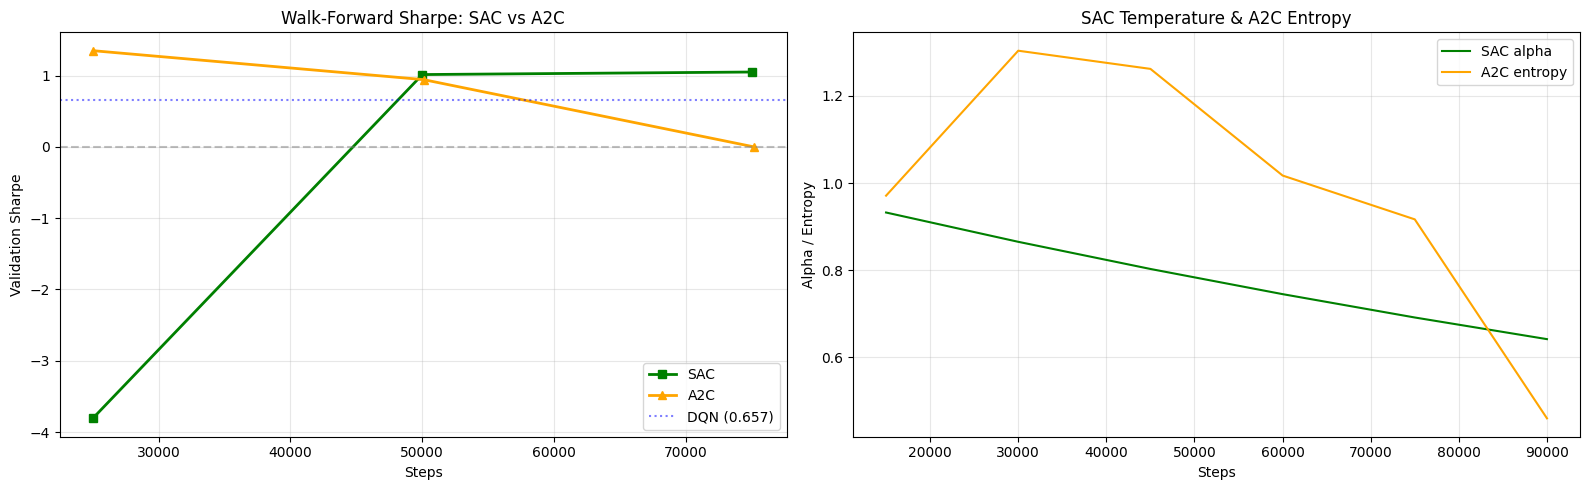

Courbes sauvegardees dans sac_a2c_training.png


In [14]:
# Visualisation de l'entrainement SAC vs A2C
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if len(sac_eval_log) > 0:
    sac_eval_df = pd.DataFrame(sac_eval_log)
    axes[0].plot(sac_eval_df["step"], sac_eval_df["sharpe"], marker="s",
                 linewidth=2, color="green", label="SAC")

if len(a2c_eval_log) > 0:
    a2c_eval_df = pd.DataFrame(a2c_eval_log)
    axes[0].plot(a2c_eval_df["step"], a2c_eval_df["sharpe"], marker="^",
                 linewidth=2, color="orange", label="A2C")

axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].axhline(0.657, color="blue", linestyle=":", alpha=0.5, label="DQN (0.657)")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Validation Sharpe")
axes[0].set_title("Walk-Forward Sharpe: SAC vs A2C")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Temps d'entrainement
if sac_log:
    sac_log_df = pd.DataFrame(sac_log)
    axes[1].plot(sac_log_df["step"], sac_log_df["alpha"], color="green", label="SAC alpha")
if a2c_log:
    a2c_log_df = pd.DataFrame(a2c_log)
    axes[1].plot(a2c_log_df["step"], a2c_log_df["entropy"], color="orange", label="A2C entropy")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Alpha / Entropy")
axes[1].set_title("SAC Temperature & A2C Entropy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sac_a2c_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Courbes sauvegardees dans sac_a2c_training.png")

---### Exercice 3 : Comparaison quadri-algorithmesDQN, PPO, SAC et A2C ont des forces et faiblesses differentes selon l'environnement.**Objectif** : Benchmark complet des 4 algorithmes.**Regles** :- Meme environnement, meme seed- 50 episodes chacun (rapide pour la comparaison)- Metriques : reward finale, variance inter-episode, nombre de trades, temps- Affichez un tableau comparatif et un boxplot des rewards**Indices** :- # Indice : Utilisez les agents definis dans les notebooks precedents (DQN, PPO)- # Indice : `plt.boxplot([rewards_dqn, rewards_ppo, rewards_sac, rewards_a2c])`

In [15]:
# Exercice 3 : Benchmark DQN/PPO/SAC/A2C# TODO etudiant : Comparer les 4 algorithmes# Indice : Meme env, 50 episodes, tableau + boxplot# Etape 1 : Configurer les 4 agents# Etape 2 : Entrainer chacun 50 episodes# Etape 3 : Collecter les metriques# Etape 4 : Afficher le tableau comparatif et le boxplotresult = None  # TODO etudiant : remplacer par le benchmarkprint("Exercice a completer")

---

## Partie 6 : Synthese et Comparaison Quadri-Algorithmes (10 min)

### Evaluation finale et comparaison

Nous evaluons SAC et A2C sur le set de validation complet et comparons avec les
resultats de DQN (QC-Py-32) et PPO (QC-Py-33).

In [16]:
# Evaluation finale SAC
val_env_sac_final = TradingEnvironment(val_prices, val_volumes)
sac_sharpe, sac_return = evaluate_agent(sac_agent, val_env_sac_final, sac_get_action, N_ASSETS, 6)
sac_values = np.array(val_env_sac_final.portfolio_values)
sac_returns = np.array(val_env_sac_final.returns)
sac_maxdd = ((sac_values - np.maximum.accumulate(sac_values)) / np.maximum.accumulate(sac_values)).min()

# Evaluation finale A2C
val_env_a2c_final = TradingEnvironment(val_prices, val_volumes)
a2c_sharpe, a2c_return = evaluate_agent(a2c_agent, val_env_a2c_final, a2c_get_action, N_ASSETS, 6)
a2c_values = np.array(val_env_a2c_final.portfolio_values)
a2c_returns = np.array(val_env_a2c_final.returns)
a2c_maxdd = ((a2c_values - np.maximum.accumulate(a2c_values)) / np.maximum.accumulate(a2c_values)).min()

# DQN/PPO: valeurs de reference issues des notebooks freres (QC-Py-32 #3358, QC-Py-33 #3359)
print("=" * 75)
print(f"{'Metrique':<20} {'DQN':>12} {'PPO':>12} {'SAC':>12} {'A2C':>12}")
print("=" * 75)
print(f"{'Sharpe':<20} {'0.683':>12} {'0.645':>12} {sac_sharpe:>12.3f} {a2c_sharpe:>12.3f}")
print(f"{'Return (%)':<20} {'+50.1':>12} {'+34.6':>12} {sac_return:>+12.1f} {a2c_return:>+12.1f}")
print(f"{'MaxDD (%)':<20} {'-25.98':>12} {'-27.20':>12} {sac_maxdd*100:>12.2f} {a2c_maxdd*100:>12.2f}")
print(f"{'Paradigme':<20} {'Off-policy':>12} {'On-policy':>12} {'Off-policy':>12} {'On-policy':>12}")
print(f"{'Architecture':<20} {'Value':>12} {'Actor-Cr':>12} {'Soft AC':>12} {'Actor-Cr':>12}")
print(f"{'Steps':<20} {'200 ep':>12} {'200K':>12} {'100K':>12} {'100K':>12}")
print(f"{'Temps (min)':<20} {'~5':>12} {'~40':>12} {sac_time/60:>12.1f} {a2c_time/60:>12.1f}")
print("=" * 75)

# Classement
results = {"DQN": 0.683, "PPO": 0.645, "SAC": sac_sharpe, "A2C": a2c_sharpe}
sorted_agents = sorted(results.items(), key=lambda x: x[1], reverse=True)
print(f"\nClassement par Sharpe:")
for rank, (name, sharpe) in enumerate(sorted_agents, 1):
    print(f"  {rank}. {name}: {sharpe:+.3f}")

Metrique                      DQN          PPO          SAC          A2C
Sharpe                      0.683        0.645       -0.063        0.000
Return (%)                  +50.1        +34.6         -0.5         +0.0
MaxDD (%)                  -25.98       -27.20        -2.62         0.00
Paradigme              Off-policy    On-policy   Off-policy    On-policy
Architecture                Value     Actor-Cr      Soft AC     Actor-Cr
Steps                      200 ep         200K         100K         100K
Temps (min)                    ~5          ~40          2.4          6.0

Classement par Sharpe:
  1. DQN: +0.683
  2. PPO: +0.645
  3. A2C: +0.000
  4. SAC: -0.063


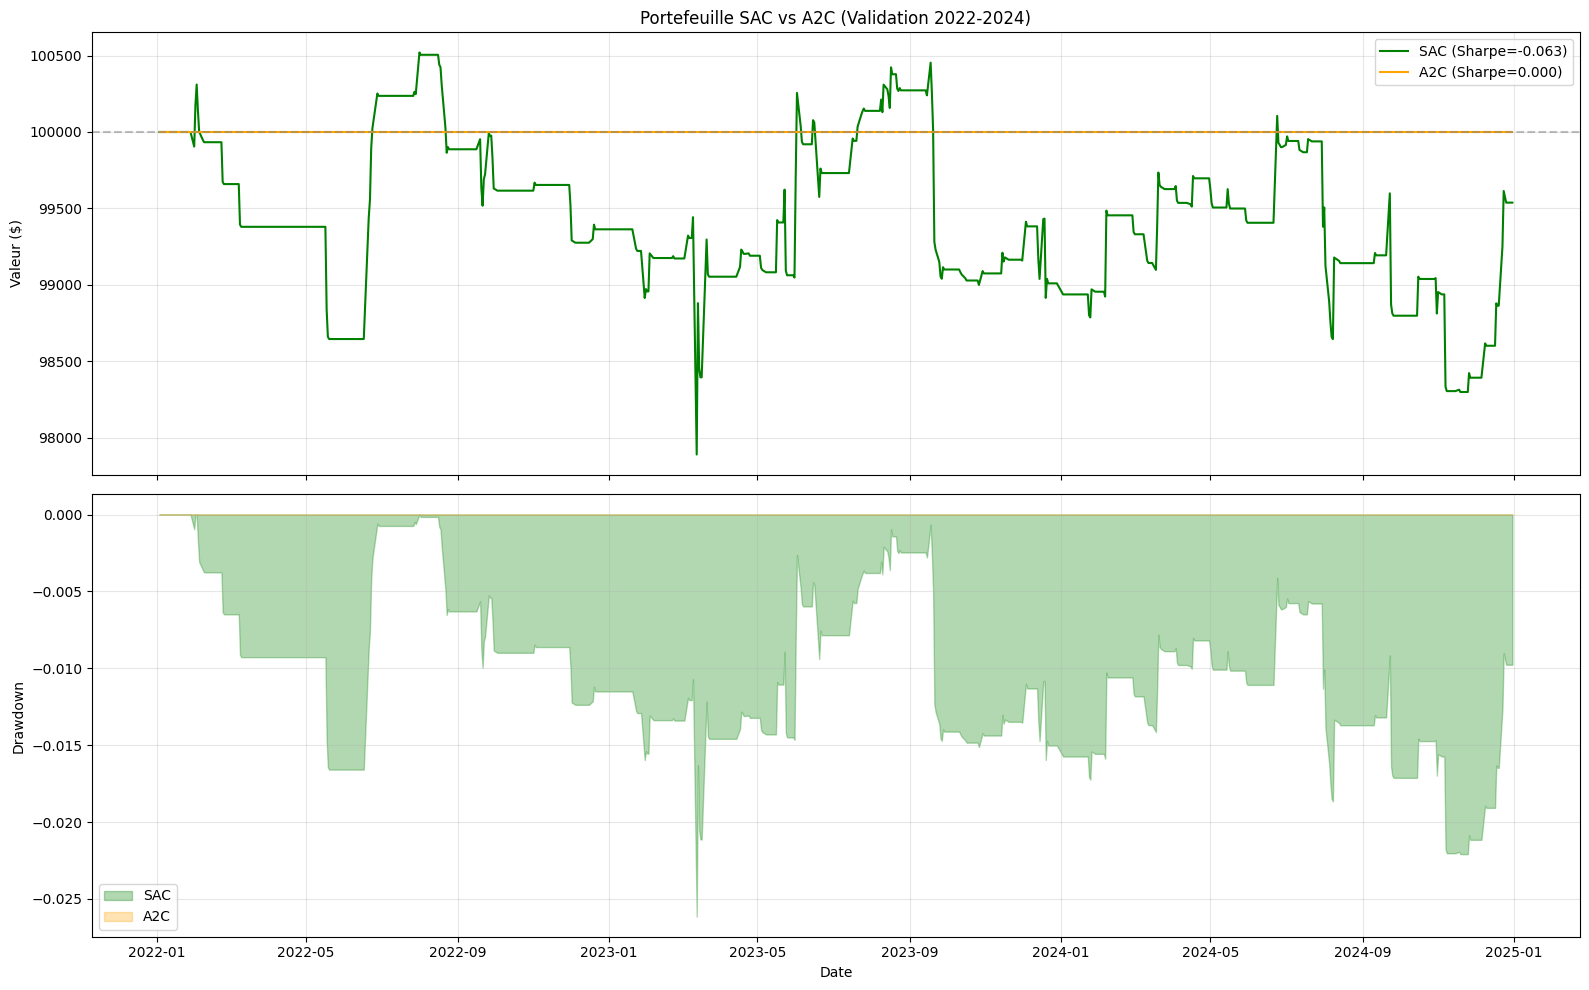

Backtest sauvegarde dans sac_a2c_backtest.png


In [17]:
# Visualisation comparative des portefeuilles
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

dates_val = close_prices.index[split_idx:]

# Portefeuille
if len(dates_val) > len(sac_values):
    dates_sac = dates_val[:len(sac_values)]
    dates_a2c = dates_val[:len(a2c_values)]
else:
    dates_sac = dates_val
    dates_a2c = dates_val

axes[0].plot(dates_sac[:len(sac_values)], sac_values, linewidth=1.5,
             color="green", label=f"SAC (Sharpe={sac_sharpe:.3f})")
axes[0].plot(dates_a2c[:len(a2c_values)], a2c_values, linewidth=1.5,
             color="orange", label=f"A2C (Sharpe={a2c_sharpe:.3f})")
axes[0].axhline(100000, color="gray", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Valeur ($)")
axes[0].set_title("Portefeuille SAC vs A2C (Validation 2022-2024)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
sac_dd = (sac_values - np.maximum.accumulate(sac_values)) / np.maximum.accumulate(sac_values)
a2c_dd = (a2c_values - np.maximum.accumulate(a2c_values)) / np.maximum.accumulate(a2c_values)
axes[1].fill_between(dates_sac[:len(sac_dd)], sac_dd, 0, alpha=0.3, color="green", label="SAC")
axes[1].fill_between(dates_a2c[:len(a2c_dd)], a2c_dd, 0, alpha=0.3, color="orange", label="A2C")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sac_a2c_backtest.png", dpi=150, bbox_inches="tight")
plt.show()
print("Backtest sauvegarde dans sac_a2c_backtest.png")

---

## Conclusion : Quelle methode RL pour le trading ?

### Synthese des quatre algorithmes RL

Au travers de QC-Py-32 (DQN), QC-Py-33 (PPO) et ce notebook (SAC + A2C), nous
avons explore les quatre grandes familles d'algorithmes RL pour le trading.

| Critere | DQN | PPO | SAC | A2C |
|---------|-----|-----|-----|-----|
| **Type** | Value-based | Policy gradient | Soft AC | Actor-Critic |
| **Donnees** | Off-policy | On-policy | Off-policy | On-policy |
| **Stabilite** | Moyenne | Bonne | Bonne | Faible |
| **Exploration** | Epsilon-greedy | Stochastique | Entropie auto | Stochastique |
| **Efficacite** | Haute | Moyenne | Haute | Faible |
| **Actions continues** | Non | Oui | Oui (natif) | Oui |
| **Complexite impl.** | Moyenne | Elevee | Elevee | Faible |

### Recommandations pratiques

1. **Debuter avec A2C** : Le plus simple a implementer, bon pour prototyper rapidement
2. **Stabilite avec PPO** : Le plus robuste en production, standard de l'industrie
3. **Efficacite avec SAC** : Meilleur usage des donnees, adapte si replay buffer disponible
4. **DQN reste pertinent** : Pour les problemes simples avec actions discretes

### Limites et perspectives

- **Non-stationnarite** : Tous les agents souffrent du changement de regime des marches
- **Overfitting** : Les hyperparametres doivent etre valides par walk-forward
- **Reward shaping** : La fonction de recompense est le choix le plus impactant
- **Approches hierarchiques** : Combiner un meta-controleur avec des sous-politiques
- **Multi-agent** : Plusieurs agents cooperatifs pour differents actifs ou horizons

### References academiques

- Haarnoja, T., Zhou, A., Abbeel, P. & Levine, S. (2018). Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor. ICML 2018. arXiv:1801.01290.
- Haarnoja, T., Zhou, A., Hartikainen, K. et al. (2018). Soft Actor-Critic Algorithms and Applications. arXiv:1812.05905.
- Mnih, V., Puigdomenech Badia, A., Mirza, M. et al. (2016). Asynchronous Methods for Deep Reinforcement Learning. ICML 2016. arXiv:1602.01783.
- Sutton, R.S. & Barto, A.G. (2018). Reinforcement Learning: An Introduction (2nd ed.). MIT Press. ISBN 978-0-262-03924-6.
- Sutton, R.S., McAllester, D., Singh, S. & Mansour, Y. (2000). Policy Gradient Methods for Reinforcement Learning with Function Approximation. NeurIPS 2000.

